# Household Power Consumption 
---

## Import libraries

In [49]:
# import basic libraries
import pandas as pd
import numpy as np
from IPython.display import display

# import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context='paper',style='darkgrid')

# For forecasting
from statsmodels.tsa.arima.model import ARIMA

# For evaluation
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# import warnings
import warnings
warnings.filterwarnings('ignore')

## Load the Dataset

In [2]:
# load the txt file
df = pd.read_csv(r'C:\Users\Bhawna\OneDrive\Desktop\Household power consumption analytics\household_power_consumption.txt', delimiter=';')

# Shape of the dataset
display(df.shape)

# Display top 5 rows
df.head()

(2075259, 9)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


## Data cleaning

In [4]:
# Checking null values
df.isna().sum()

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

In [5]:
# Replace question marks to null values
df.replace('?', pd.NA, inplace=True)

In [6]:
# After replacing, check null values again
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [7]:
# Drop null values
df.dropna(inplace=True)

# After removing null values
print('Shape of Power Consumption Data after removing null values:',df.shape)

Shape of Power Consumption Data after removing null values: (2049280, 9)


In [8]:
# Change the datatypes of the columns

df['Global_active_power'] = df['Global_active_power'].astype('float')
df['Global_reactive_power'] = df['Global_reactive_power'].astype('float')
df['Voltage'] = df['Voltage'].astype('float')
df['Global_intensity'] = df['Global_intensity'].astype('float')
df['Sub_metering_1'] = df['Sub_metering_1'].astype('float')
df['Sub_metering_2'] = df['Sub_metering_2'].astype('float')
df['Sub_metering_3'] = df['Sub_metering_3'].astype('float')

In [ ]:
# Merge Date + Time into single datetime column
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],
                                format='%d/%m/%Y %H:%M:%S')

# Set datetime as index
df.set_index('DateTime', inplace=True)

In [17]:
# Removing unnecessary columns
df.drop(['Date','Time'], axis=1, inplace=True)

In [20]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Exploartory Data Analysis

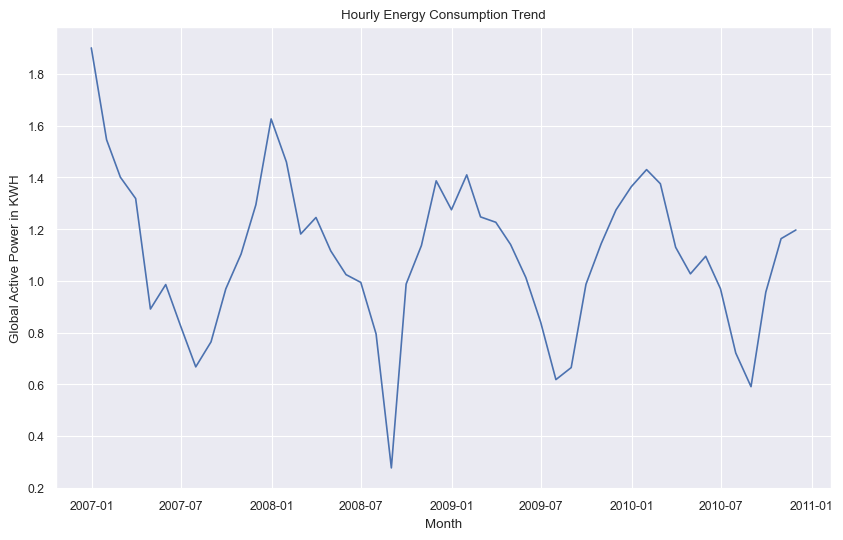

In [27]:
## Monthly consumption

# Monthly resampling
monthly_df = df.resample('M').mean()

# Plot
plt.figure(figsize=(10,6))
plt.plot(monthly_df.index, monthly_df['Global_active_power'])
plt.title("Hourly Energy Consumption Trend")
plt.xlabel("Month")
plt.ylabel("Global Active Power in KWH")
plt.show()

In [38]:
## Average Daily Consumption
avg_daily = df['Global_active_power'].resample('D').mean().mean()
print("Average Daily Consumption: ", avg_daily)

## Peak Usage Hours
hourly_avg = df['Global_active_power'].resample('H').mean()
peak_hour = hourly_avg.idxmax().hour
print("Peak Usage Hour: ", peak_hour)

## Monthly Bill if 6 ruppees per kWh
monthly_consumption = df['Global_active_power'].resample('M').sum()
monthly_bill = monthly_consumption * 6 
print("Monthly Bill in INR: ")
print(monthly_bill)

Average Daily Consumption:  1.09204830160128
Peak Usage Hour:  18
Monthly Bill in INR: 
DateTime
2006-12-31    250879.692
2007-01-31    414071.172
2007-02-28    338933.316
2007-03-31    353173.152
2007-04-30    211088.796
2007-05-31    264053.232
2007-06-30    214096.968
2007-07-31    178222.980
2007-08-31    204578.760
2007-09-30    251235.636
2007-10-31    295658.220
2007-11-30    335511.864
2007-12-31    435625.020
2008-01-31    391016.292
2008-02-29    295986.432
2008-03-31    333543.564
2008-04-30    289259.952
2008-05-31    274331.160
2008-06-30    257663.832
2008-07-31    212864.508
2008-08-31     74051.280
2008-09-30    256006.752
2008-10-31    304178.760
2008-11-30    359452.560
2008-12-31    341003.472
2009-01-31    377700.048
2009-02-28    301332.540
2009-03-31    328553.916
2009-04-30    295653.144
2009-05-31    271258.980
2009-06-30    201251.880
2009-07-31    165542.664
2009-08-31    174458.424
2009-09-30    255771.384
2009-10-31    306532.320
2009-11-30    330405.852
200

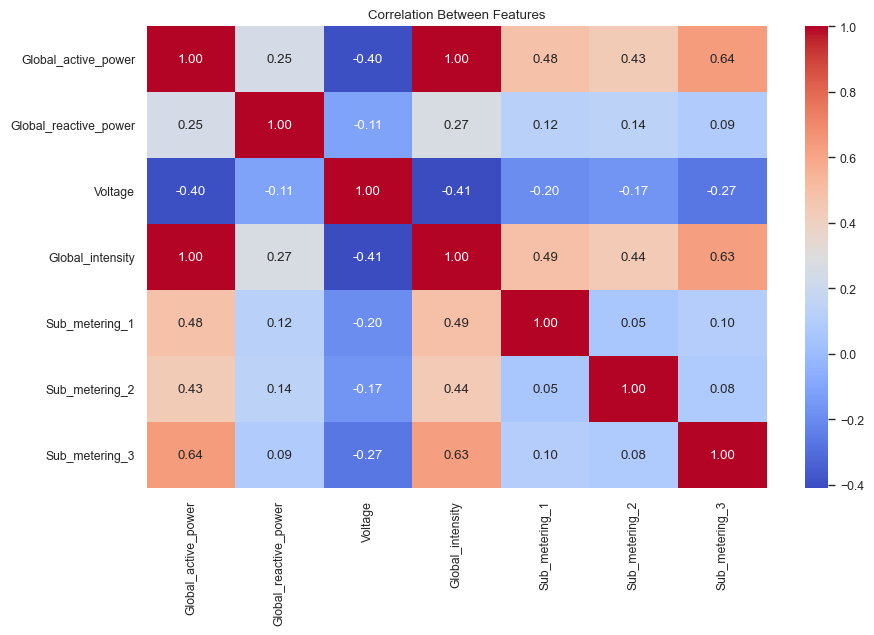

In [28]:
## Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Between Features")
plt.show()

## Forecasting model (ARIMA)

In [60]:
# Forecasting for next 7 days

## Daily average
daily_df = df['Global_active_power'].resample('D').mean()

## Train test split
train_size = int(len(daily_df) * 0.8)
train, test = daily_df[:train_size], daily_df[train_size:]

## Fit ARIMA model
model = ARIMA(train, order=(3,1,3))
model_fit = model.fit()

## Forecast next 7 days
forecast = model_fit.forecast(steps=7)

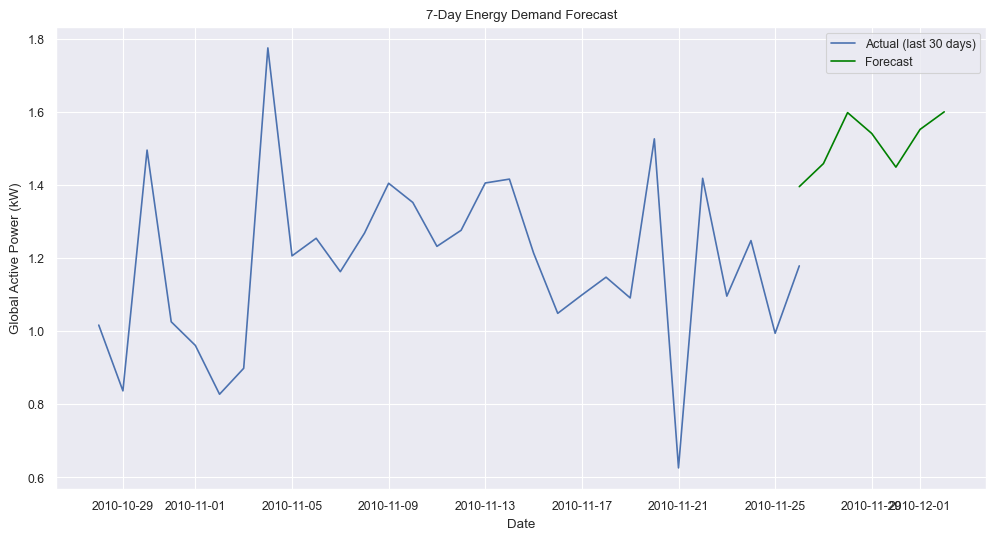

In [61]:
## Plot Actual vs Forecast
plt.figure(figsize=(12,6))
plt.plot(daily_df.index[-30:], daily_df[-30:], label='Actual (last 30 days)')
plt.plot(pd.date_range(daily_df.index[-1], periods=7, freq='D'), forecast,
         label='Forecast', color='green')
plt.title("7-Day Energy Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()

## Evaluation

In [79]:
## Evaluation using mae and rmse
pred = model_fit.predict(start=test.index[0], end=test.index[-1])

mae = mean_absolute_error(test, pred)
rmse = root_mean_squared_error(test, pred)
print("MAE:", mae, "RMSE:", rmse)

MAE: 0.3982035408823557 RMSE: 0.49851607853414476
